In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from data_generation import generate_data
from tokenizer import tokenizer
from train import train

print(torch.cuda.is_available())


In [ ]:
# TRAINING ASSISTANT FUNCTION

def model_function(operator: str, split: float, lr: float):
  train_set, val_set, _ = generate_data(
          p=97,
          train_split=split,
          val_split=1 - split,
          ops=[operator],
          seed=42)

  epochs = 2000 #10**6 // 512
  tok = tokenizer()
  tok.build_vocab(train_set + val_set)

  metrics, model = train(
          tok,
          train_set,
          val_set,
          batch_size=512,
          block_size=16,
          n_layer=2,
          n_head=4,
          n_embd=128,
          dropout=0.1,
          bias=True,
          learning_rate=lr,
          epochs=epochs,
          seed=42,
          output_dir=None,
          intermediate_ckpt=False,
          verbose=True,
          weight_decay=1.0,
          beta1=0.9,
          beta2=0.98,
          warmup_steps=10)

  train_loss = metrics["combined"]["train_losses"]
  train_accuracy = metrics["combined"]["train_accs"]
  val_loss = metrics["combined"]["val_losses"]
  val_accuracy = metrics["combined"]["val_accs"]

  return(train_loss, train_accuracy, val_loss, val_accuracy)


In [28]:
# MODEL TRAINING FOR 1.4 STUDY 1

train_loss_25, train_accuracy_25, val_loss_25, val_accuracy_25 = model_function(operator='/', split=0.25, lr=1e-3)
train_loss_23, train_accuracy_23, val_loss_23, val_accuracy_23 = model_function(operator='/', split=0.23, lr=1e-3)
train_loss_20, train_accuracy_20, val_loss_20, val_accuracy_20 = model_function(operator='/', split=0.20, lr=1e-3)
train_loss_18, train_accuracy_18, val_loss_18, val_accuracy_18 = model_function(operator='/', split=0.18, lr=1e-3)

number of parameters: 0.41M


training: 100%|██████████| 2000/2000 [09:13<00:00,  3.61it/s, train_acc=0.999, train_loss=0.0111, val_acc=0.998, val_loss=0.0111]


number of parameters: 0.41M


training: 100%|██████████| 2000/2000 [08:38<00:00,  3.86it/s, train_acc=0.999, train_loss=0.0181, val_acc=1, val_loss=0.00335]


number of parameters: 0.41M


training: 100%|██████████| 2000/2000 [08:55<00:00,  3.74it/s, train_acc=0.994, train_loss=0.0492, val_acc=1, val_loss=0.00506]


number of parameters: 0.41M


training: 100%|██████████| 2000/2000 [08:49<00:00,  3.78it/s, train_acc=0.999, train_loss=0.0236, val_acc=1, val_loss=0.00463]


25% model reached accuracy of 1 at epoch: 513
23% model reached accuracy of 1 at epoch: 884
20% model reached accuracy of 1 at epoch: 1212
18% model reached accuracy of 1 at epoch: 1781


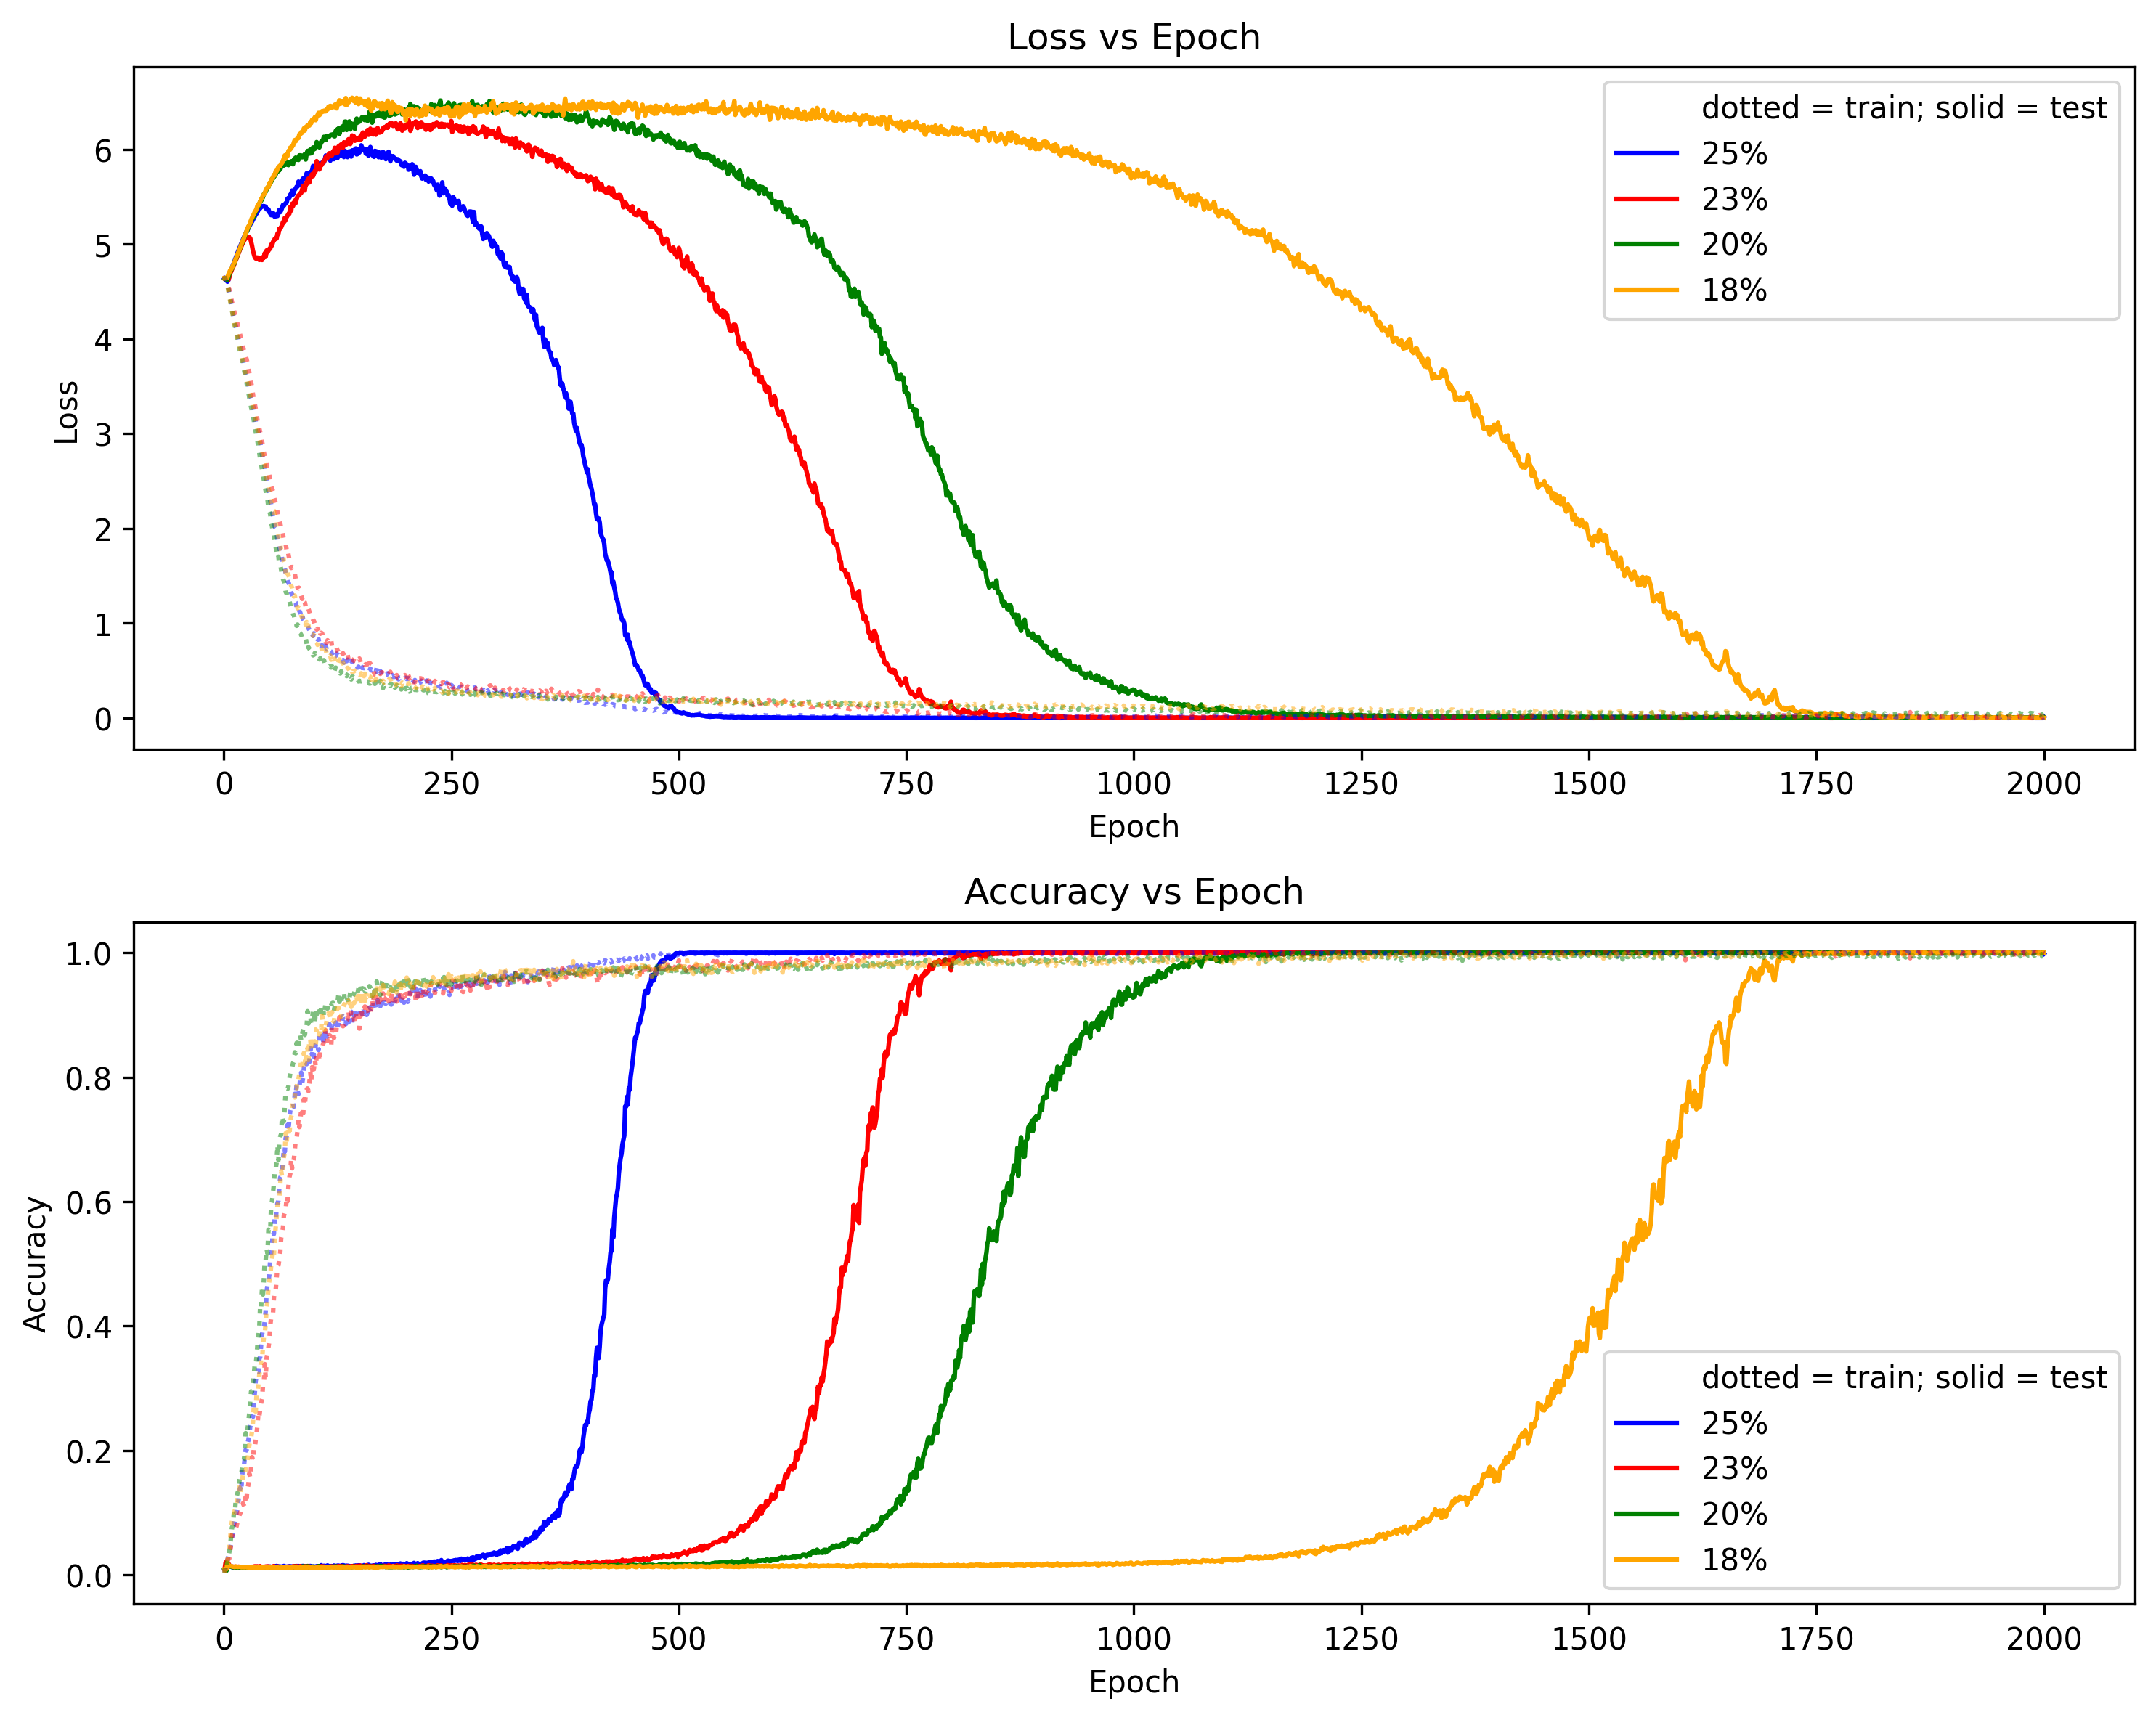

In [31]:
# DEVELOPING GRAPHS AND EPOCH AT 100% TEST FOR 1.4 STUDY 1

print(f"25% model reached accuracy of 1 at epoch: {val_accuracy_25.index(1)}")
print(f"23% model reached accuracy of 1 at epoch: {val_accuracy_23.index(1)}")
print(f"20% model reached accuracy of 1 at epoch: {val_accuracy_20.index(1)}")
print(f"18% model reached accuracy of 1 at epoch: {val_accuracy_18.index(1)}")


X = np.arange(1, 2000+1, 1)

fig, axs = plt.subplots(2, figsize=(10, 8), dpi=300)
#fig.suptitle(f"Accuracy and Loss Graphs for p=97 under the Division Operator Training on 25% of Total Data")

axs[0].scatter(1000, 0.2, color="white", label="dotted = train; solid = test")
axs[0].plot(X, val_loss_25, color="blue", label="25%")
axs[0].plot(X, val_loss_23, color="red", label="23%")
axs[0].plot(X, val_loss_20, color="green", label="20%")
axs[0].plot(X, val_loss_18, color="orange", label="18%")


axs[0].plot(X, train_loss_25, color="blue", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_23, color="red", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_20, color="green", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_18, color="orange", linestyle=':', alpha=0.5)

axs[0].set_title("Loss vs Epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend(loc="upper right")



axs[1].scatter(1000, 0.2, color="white", label="dotted = train; solid = test")
axs[1].plot(X, val_accuracy_25, color="blue", label="25%")
axs[1].plot(X, val_accuracy_23, color="red", label="23%")
axs[1].plot(X, val_accuracy_20, color="green", label="20%")
axs[1].plot(X, val_accuracy_18, color="orange", label="18%")


axs[1].plot(X, train_accuracy_25, color="blue", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_23, color="red", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_20, color="green", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_18, color="orange", linestyle=':', alpha=0.5)

axs[1].set_title("Accuracy vs Epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend(loc="lower right")

fig.tight_layout()
plt.show()

In [ ]:
# MODEL TRAINING FOR 1.4 STUDY 2

train_loss_1e3, train_accuracy_1e3, val_loss_1e3, val_accuracy_1e3 = model_function(operator='/', split=0.18, lr=1e-3)
train_loss_3e3, train_accuracy_3e3, val_loss_3e3, val_accuracy_3e3 = model_function(operator='/', split=0.18, lr=3e-3)
train_loss_5e3, train_accuracy_5e3, val_loss_5e3, val_accuracy_5e3 = model_function(operator='/', split=0.18, lr=5e-3)
train_loss_8e3, train_accuracy_8e3, val_loss_8e3, val_accuracy_8e3 = model_function(operator='/', split=0.18, lr=8e-3)
train_loss_9e3, train_accuracy_9e3, val_loss_9e3, val_accuracy_9e3 = model_function(operator='/', split=0.18, lr=9e-3)
train_loss_1e2, train_accuracy_1e2, val_loss_1e2, val_accuracy_1e2 = model_function(operator='/', split=0.18, lr=1e-2)
train_loss_2e2, train_accuracy_2e2, val_loss_2e2, val_accuracy_2e2 = model_function(operator='/', split=0.18, lr=2e-2)
#train_loss_3e2, train_accuracy_3e2, val_loss_3e2, val_accuracy_3e2 = model_function(operator='/', split=0.18, lr=3e-2)


lr=1e-3 model reached accuracy of 1 at epoch: 1781
r=3e-3 model reached accuracy of 1 at epoch: 625
lr=5e-3 model reached accuracy of 1 at epoch: 658
lr=8e-3 model reached accuracy of 1 at epoch: 337
lr=9e-3 model reached accuracy of 1 at epoch: 451
lr=1e-2 model reached accuracy of 1 at epoch: 329


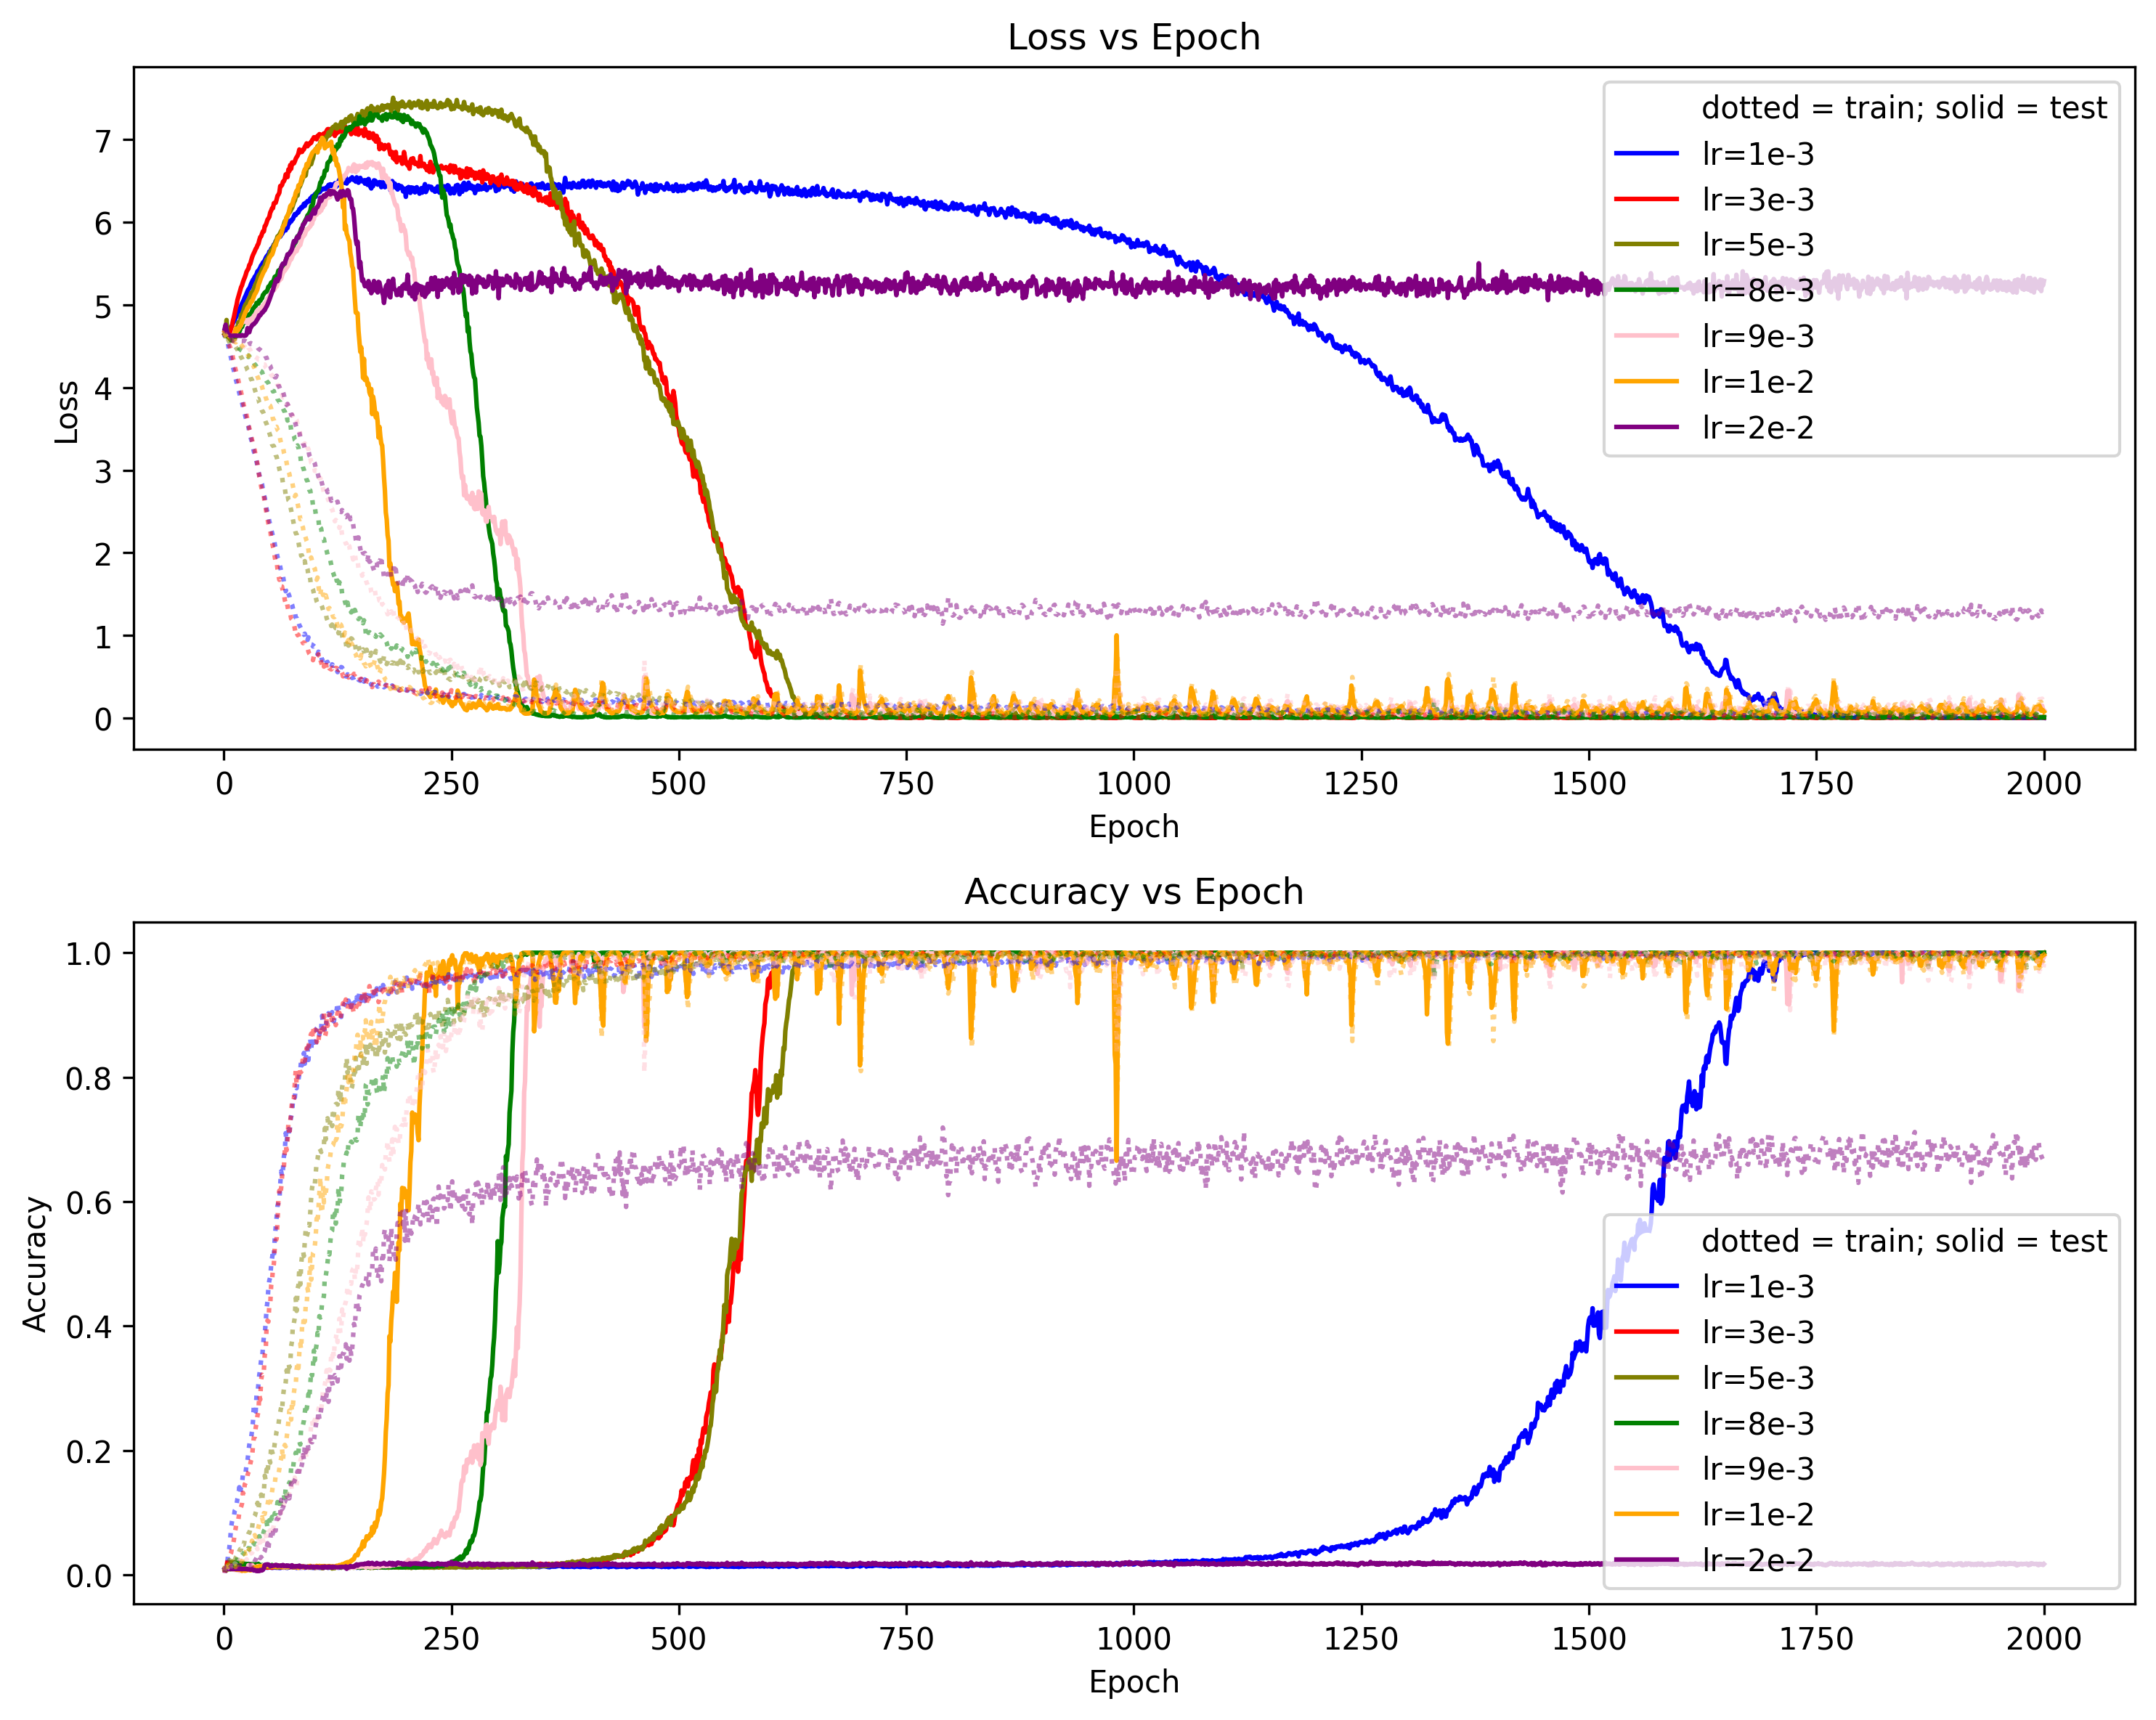

In [27]:
# DEVELOPING GRAPHS AND EPOCH AT 100% TEST FOR 1.4 STUDY 2

print(f"lr=1e-3 model reached accuracy of 1 at epoch: {val_accuracy_1e3}")
print(f"r=3e-3 model reached accuracy of 1 at epoch: {val_accuracy_3e3}")
print(f"lr=5e-3 model reached accuracy of 1 at epoch: {val_accuracy_5e3}")
print(f"lr=8e-3 model reached accuracy of 1 at epoch: {val_accuracy_8e3}")
print(f"lr=9e-3 model reached accuracy of 1 at epoch: {val_accuracy_9e3}")
print(f"lr=1e-2 model reached accuracy of 1 at epoch: {val_accuracy_1e2}")
X = np.arange(1, 2000+1, 1)

fig, axs = plt.subplots(2, figsize=(10, 8), dpi=300)
#fig.suptitle(f"Accuracy and Loss Graphs for p=97 under the Division Operator Training on 25% of Total Data")

axs[0].scatter(1000, 0.2, color="white", label="dotted = train; solid = test")
axs[0].plot(X, val_loss_1e3, color="blue", label="lr=1e-3")
axs[0].plot(X, val_loss_3e3, color="red", label="lr=3e-3")
axs[0].plot(X, val_loss_5e3, color="olive", label="lr=5e-3")
axs[0].plot(X, val_loss_8e3, color="green", label="lr=8e-3")
axs[0].plot(X, val_loss_9e3, color="pink", label="lr=9e-3")
axs[0].plot(X, val_loss_1e2, color="orange", label="lr=1e-2")
axs[0].plot(X, val_loss_2e2, color="purple", label="lr=2e-2")

axs[0].plot(X, train_loss_1e3, color="blue", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_3e3, color="red", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_5e3, color="olive", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_8e3, color="green", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_9e3, color="pink", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_1e2, color="orange", linestyle=':', alpha=0.5)
axs[0].plot(X, train_loss_2e2, color="purple", linestyle=':', alpha=0.5)

axs[0].set_title("Loss vs Epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend(loc="upper right")



axs[1].scatter(1000, 0.2, color="white", label="dotted = train; solid = test")
axs[1].plot(X, val_accuracy_1e3, color="blue", label="lr=1e-3")
axs[1].plot(X, val_accuracy_3e3, color="red", label="lr=3e-3")
axs[1].plot(X, val_accuracy_5e3, color="olive", label="lr=5e-3")
axs[1].plot(X, val_accuracy_8e3, color="green", label="lr=8e-3")
axs[1].plot(X, val_accuracy_9e3, color="pink", label="lr=9e-3")
axs[1].plot(X, val_accuracy_1e2, color="orange", label="lr=1e-2")
axs[1].plot(X, val_accuracy_2e2, color="purple", label="lr=2e-2")

axs[1].plot(X, train_accuracy_1e3, color="blue", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_3e3, color="red", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_5e3, color="olive", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_8e3, color="green", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_9e3, color="pink", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_1e2, color="orange", linestyle=':', alpha=0.5)
axs[1].plot(X, train_accuracy_2e2, color="purple", linestyle=':', alpha=0.5)

axs[1].set_title("Accuracy vs Epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend(loc="lower right")

fig.tight_layout()
plt.show()
#print(len(train_set)/(len(train_set)+len(test_set)))